<a href="https://colab.research.google.com/github/RadhaKalluri/Nowak-Kalluri_TypeIISGN2026_FullRepository/blob/main/Copy_for_Nate_TypeII_AnodeBreak4112025_BulkDraw_RitterforIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas
!pip install numpy
!pip install brian2
!pip install brian2tools
!pip install matplotlib-venn
import pandas as pd
import numpy as np
from brian2 import *
import math

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.8/390.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 5.8 MB/s eta 0:00:00


In [ ]:
defaultclock.dt = 0.01*ms
start_scope()
# Channels
#C = 12*pF
Eh = -43*mV
EK = -81*mV  # -77*mV in mod file
El = -65*mV
ENa = 82*mV

#Rothman and Manis Parameters
nf = 0.85  # proportion of n vs p kinetics
zss = 0.5 # steady state inactivation of glt
temp = 22.  # temperature in degree celcius
q10 = 3. ** ((temp - 22) / 10.)
# hcno current (octopus cell)
frac = 0.0
qt = 4.5 ** ((temp - 33.) / 10.)

# Classical Na channel  #This implementation incorporates the tweaks from Kalluri and Hight
eqs_na = """
ina = gnabar*m**3*h*(ENa-v) : amp/metre**2
dm/dt=q10*(minf-m)/mtau : 1
dh/dt=q10*(hinf-h)/htau : 1
minf = 1./(1+exp(-(vu + 38.) / 7.)) : 1
hinf = 1./(1+exp((vu + 65.) / 6.)) : 1
mtau =  ((10. / (5*exp((vu+60.) / 18.) + 36.*exp(-(vu+60.) / 25.))) + 0.04)*ms : second
htau =  ((100. / (7*exp((vu+60.) / 11.) + 10.*exp(-(vu+60.) / 25.))) + 0.6)*ms : second
gnabar: siemens/metre**2
"""
# KHT channel (delayed-rectifier K+); note that ptau is different than in the implementation shown in Brian for Rothman and Manis ptau = ((100. / (4*exp((vu+60) / 32.) + 5*exp(-(vu+60) / 22.))) + 5)*ms : second
eqs_kht = """
ikht = gkhtbar*(nf*n**2 + (1-nf)*p)*(EK-v) : amp/metre**2
dn/dt=q10*(ninf-n)/ntau : 1
dp/dt=q10*(pinf-p)/ptau : 1
ninf =   (1 + exp(-(vu + 15) / 5.))**-0.5 : 1
pinf =  1. / (1 + exp(-(vu + 23) / 6.)) : 1
ntau =  ((100. / (11*exp((vu+60) / 24.) + 21*exp(-(vu+60) / 23.))) + 0.7)*ms : second
ptau = ((100. / (4*exp((vu+60) / 32.) + 16*exp(-(vu+60) / 22.))) + 5)*ms : second
gkhtbar: siemens/metre**2
"""
# Ih channel (subthreshold adaptive, non-inactivating)  rinf is now positioned at -96 mV rather than at 76 as it is in Rothman and Manis
#eqs_ih = """
#ih = ghbar*r*(Eh-v) : amp/metre**2
#dr/dt=q10*(rinf-r)/rtau : 1
#rinf = 1. / (1+exp((vu + 100.) / 7.)) : 1
#rtau = ((100000. / (237.*exp((vu+60.) / 12.) + 17.*exp(-(vu+60.) / 14.))) + 25.)*ms : second
#ghbar: siemens/metre**2
#"""

eqs_ih = """
ih = ghbar*r*(Eh-v) : amp/metre**2
dr/dt=q10*(rinf-r)/rtau : 1
rinf = 1. / (1+exp((vu + 100.) / 8.)) : 1
rtau = ((100000. / (237.*exp((vu+60.) / 12.) + 17.*exp(-(vu+60.) / 14.))) + 25.)*ms : second
ghbar: siemens/metre**2
"""

# KLT channel (low threshold K+)#winf = (1. / (1 + exp(-(vu + 48.) / 6.)))**0.25 : 1
eqs_klt = """
iklt = gkltbar*w**4*z*(EK-v) : amp/metre**2
dw/dt=q10*(winf-w)/wtau : 1
dz/dt=q10*(zinf-z)/ztau : 1
winf = (1. / (1 + exp(-(vu + 48.) /8.)))**0.25 : 1
zinf = zss + ((1.-zss) / (1 + exp((vu + 71.) / 10.))) : 1
wtau = ((100. / (6.*exp((vu+60.) / 6.) + 16.*exp(-(vu+60.) / 45.))) + 1.5)*ms : second
ztau = ((1000. / (exp((vu+60.) / 20.) + exp(-(vu+60.) / 8.))) + 50)*ms : second
gkltbar: siemens/metre**2
"""

# Ka channel (transient K+) ainf = (1. / (1 + exp(-(vu + 31) / 6.)))**0.25; binf = 1. / (1 + exp((vu + 66) / 7.))**0.5 : 1
#cinf = 1. / (1 + exp((vu + 66) / 7.))**0.5 : 1
#eqs_ka = """
#ika = gkabar*a**4*b*c*(EK-v): amp/metre**2
#da/dt=q10*(ainf-a)/atau : 1
#db/dt=q10*(binf-b)/btau : 1
#dc/dt=q10*(cinf-c)/ctau : 1
#ainf = (1. / (1 + exp(-(vu + 31) / 6.)))**0.25 : 1
#binf = 1. / (1 + exp((vu + 66) / 7.))**0.5 : 1
#cinf = 1. / (1 + exp((vu + 66) / 7.))**0.5 : 1
#atau =  ((100. / (7*exp((vu+60) / 14.) + 29*exp(-(vu+60) / 24.))) + 0.1)*ms : second
#btau =  ((1000. / (14*exp((vu+60) / 27.) + 29*exp(-(vu+60) / 24.))) + 1)*ms : second
#ctau = ((90. / (1 + exp((-66-vu) / 17.))) + 10)*ms : second
#gkabar: siemens/metre**2
#"""

# Transient K current, modified the Rothman et al model which was based on a low-voltage gated transient K+ current that had Kv4 like properties.  Modified the activation range to be more like Kv3.4-like which is consistent with the more depolarized activation range and the rapid activation kinetics.  Simplified the tau expressions to reflect the simple n-type kinetics of channel activation reported in DRG. Ritter et al. xx
#DRG Zemel et al. 2019; Kazmerek et al. 2017; Alexander 2022; and approximately fits with reported data from SGN Jagger and Houseley 2003; Note that the activation kinetics are also simplified to reflect the N-type gating that has been reported for Kv3.4.  No phophorylation related modulation is enabled.
eqs_ka = """
ika = gkabar*a**3*b*(EK-v): amp/metre**2
da/dt=q10*(ainf-a)/atau : 1
db/dt=q10*(binf-b)/btau : 1
ainf = (1. / (1 + exp(-(vu + 12) / 12.)))**0.33 : 1
binf = 1. / (1 + exp((vu + 76) / 20.)) : 1
atau = 1.5 *ms: second
btau = (6 + 20/(1 + exp((vu + 20)/10)))*ms : second
gkabar: siemens/metre**2
"""

# Leak
eqs_leak = """
ileak = gl*(El-v) : amp/metre**2
gl: siemens/metre**2
"""

In [ ]:
C = 1*uF/cm**2
eqs = """
dv/dt = (1/C)*(ileak + ina + ikht + iklt + ika + ih) + I/(C*S): volt
vu = v/mV : 1  # unitless v
I : amp
S : metre**2
"""
eqs += eqs_leak + eqs_na + eqs_kht + eqs_klt + eqs_ka + eqs_ih #add other channels when ready

In [ ]:
Cp1 = 10*pF
Cp2 = 6*pF
S1 = Cp1/C
S2 = Cp2/C
refractory_period = 15*ms
v_thresh = -40*mV

In [ ]:
num_groups = 50 # Total number of neuron groups
N = 15  # Number of neurons per group

# Define parameter distributions (example ranges)
gl_mean = 0.03e-3  # Mean value for gl
gl_std = 0.01e-3   # Standard deviation for gl
gnabar_mean = 8e-3  # Mean value for gnabar
gnabar_std = 2e-3   # Standard deviation for gnabar
gkhtbar_mean = 1e-3  # Mean value for gkhtbar
gkhtbar_std = 0.75e-3   # Standard deviation for gkhtbar
gkltbar_mean = 1e-3  # Mean value for gkltbar
gkltbar_std = 0.75e-3   # Standard deviation for gkltbar
gkabar_mean = 0.7e-3 # Mean value for gkabar
gkabar_std = 0.2e-3 # Standard deviation for gkabar
#ghbar_mean = 3e-3 # Mean value for ghbar
#ghbar_std = 1e-3 # Standard deviation for ghbar
ghbar_mean = 0.9e-3 # Mean value for ghbar
ghbar_std = 0.2e-3 # Standard deviation for ghbar

# Create neuron groups with random parameters
neuron_groups = []
neuron_labels = []
state_monitors = []
spike_monitors = []

for i in range(num_groups):
    # Draw random parameters from normal distributions and ensure they are non-negative
    gl = np.maximum(0, np.random.normal(gl_mean, gl_std))
    gnabar = np.maximum(0, np.random.normal(gnabar_mean, gnabar_std))
    gkhtbar = np.maximum(0, np.random.normal(gkhtbar_mean, gkhtbar_std))
    gkltbar = np.maximum(0, np.random.normal(gkltbar_mean, gkltbar_std))
    gkabar = np.maximum(0, np.random.normal(gkabar_mean, gkabar_std))
    ghbar = np.maximum(0, np.random.normal(ghbar_mean, ghbar_std))


    # Create neuron group with these parameters
    neurons = NeuronGroup(N, model=eqs, threshold='v > v_thresh', refractory=refractory_period, method='exponential_euler')
    neurons.v = -65*mV
    neurons.S = S1
    neurons.gl = gl * siemens/cm**2
    neurons.gnabar = gnabar * siemens/cm**2
    neurons.gkhtbar = gkhtbar * siemens/cm**2
    neurons.gkltbar = gkltbar * siemens/cm**2
    neurons.gkabar = gkabar * siemens/cm**2
    neurons.ghbar = ghbar * siemens/cm**2


    # Append to lists
    neuron_groups.append(neurons)
    neuron_labels.append(f'Neuron Group {i+1}')
    #state_monitors.append(StateMonitor(neurons, ['v', 'I','iklt','ina'],record=True))
    state_monitors.append(StateMonitor(neurons, ['v', 'I'],record=True))
    spike_monitors.append(SpikeMonitor(neurons))

In [ ]:
network = Network(neuron_groups, state_monitors, spike_monitors)  # Explicitly add monitors
Ihold = 0*pA
Istep = np.linspace(-1000, 0, N) * pA
# Run your simulation using the network

for neurons in neuron_groups:
    neurons.I = Ihold

# Run for initial settling period
network.run(200*ms)
#network.run(1000 * ms)

# Apply current steps to all neuron groups
for neurons in neuron_groups:
    neurons.I = Istep + Ihold

# Run with current injection (increased duration)
network.run(100 * ms)

# Reset to holding current for all neuron groups
for neurons in neuron_groups:
    neurons.I = Ihold

# Final run to let neurons return to rest
network.run(100 * ms)

WARNING    'ghbar' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value np.float64(0.0008492983065823015). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gkabar' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value np.float64(0.000605201903432939). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gkhtbar' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value np.float64(0.002059286572587485). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'gkltbar' is an internal variable of group 'neurongroup_10', but also exists in the run namespace with the value np.float64(0.0004794599551857238). The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
W

In [ ]:
state_monitors[0].v[0,:]

array([-65.        , -65.        , -64.99999999, ..., -58.057702  ,
       -58.05780892, -58.05791584]) * mvolt

The following lines use several Python features to iterate through your neuron groups and their associated data:

zip(neuron_groups, state_monitors, neuron_labels):

zip is a built-in Python function that takes multiple iterables (like lists or tuples) as input and returns an iterator of tuples. Each tuple contains corresponding elements from the input iterables.
In this case, it combines your neuron_groups, state_monitors, and neuron_labels lists. So, the first tuple from the zip iterator would contain the first neuron group, its corresponding StateMonitor, and its label, and so on.
enumerate(zip(...)):

enumerate is another built-in Python function that takes an iterable as input and returns an iterator of tuples. Each tuple contains an index (starting from 0) and the corresponding element from the input iterable.
Here, it takes the output of zip (the tuples of neuron group, StateMonitor, and label) and adds an index to each tuple.
for i, (neurons, mon_s, label) in ...:

This is the actual for loop. It iterates through the output of enumerate(zip(...)).
In each iteration:
i is assigned the index (0, 1, 2, ...).
neurons is assigned the current neuron group.
mon_s is assigned the current StateMonitor.
label is assigned the current neuron group label.
In simpler terms:

The for loop is designed to process each neuron group one by one. In each iteration, it gives you access to:

i: The index of the current neuron group (0 for the first group, 1 for the second, and so on).
neurons: The actual neuron group object (e.g., neurons1, neurons2, etc.).
mon_s: The StateMonitor associated with the current neuron group (e.g., mon_s1, mon_s2, etc.).
label: The label for the current neuron group (e.g., 'Neuron Type 1', 'Neuron Type 2', etc.).
This way, you can easily use these variables inside the loop to perform operations specific to each neuron group, like accessing their recorded data, applying offsets, and plotting them in separate subplots.

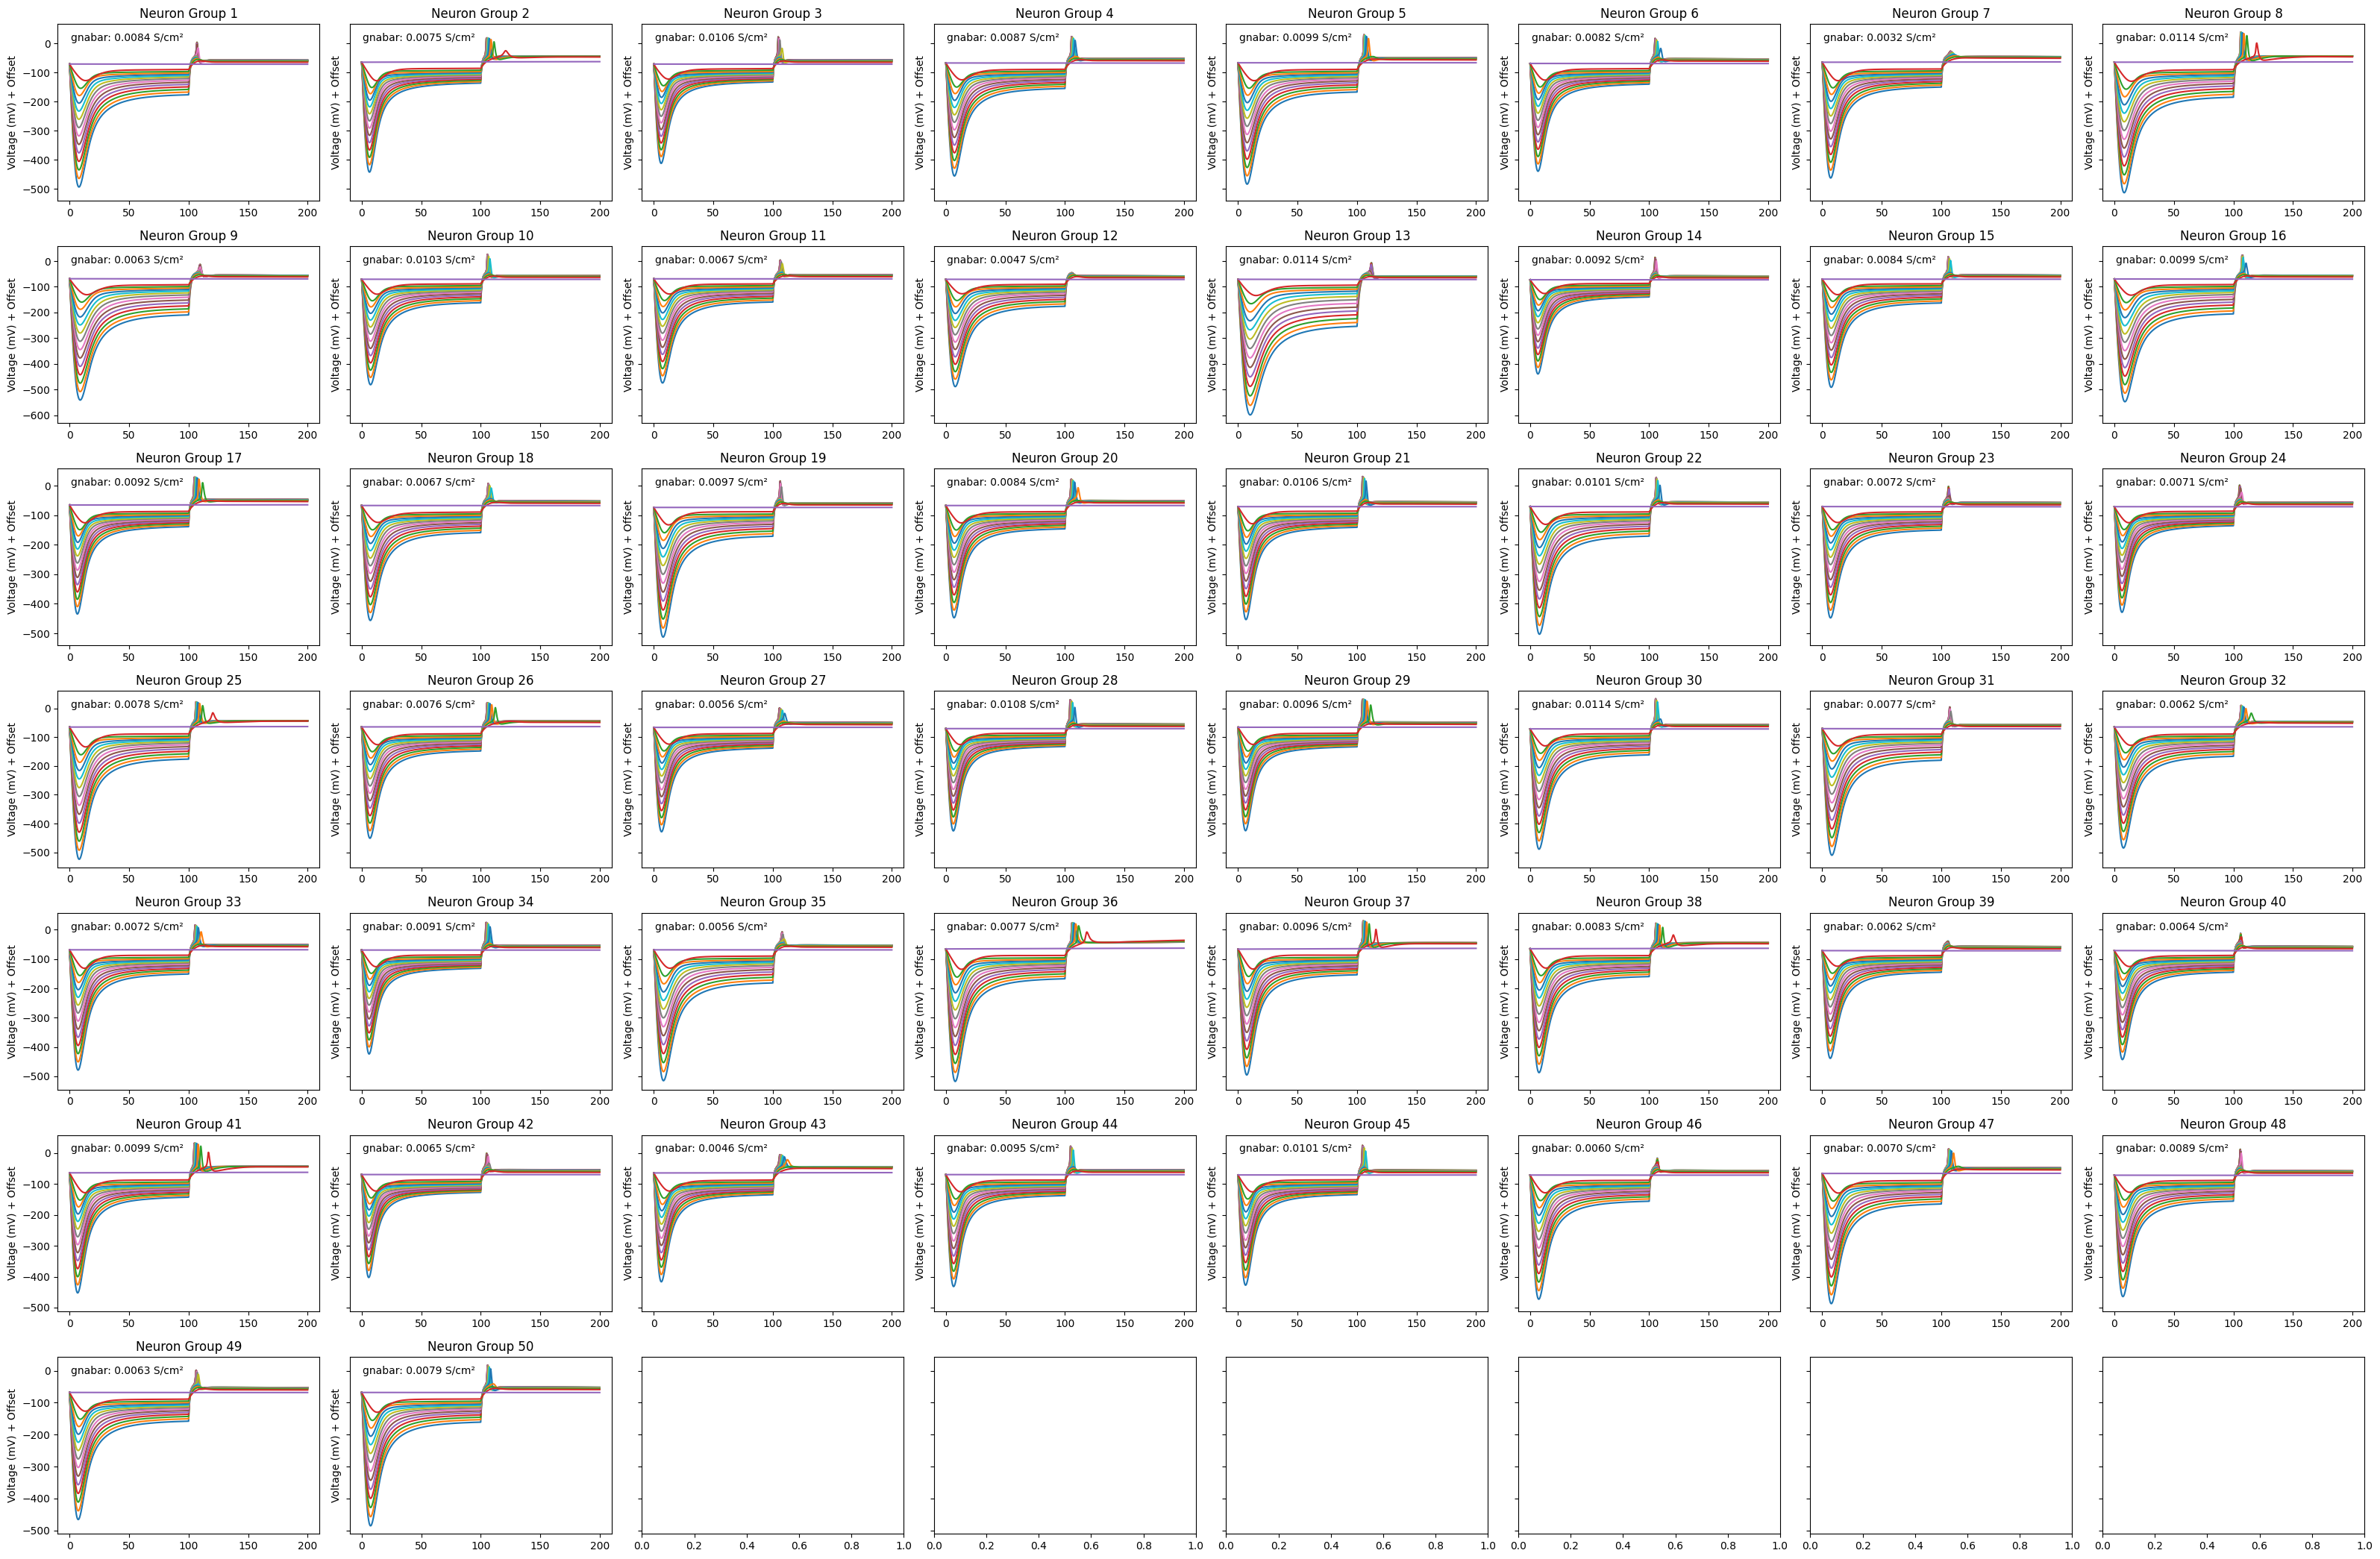

In [ ]:
neuron_labels = [f'Neuron Group {i+1}' for i in range(num_groups)]

# Automatically determine grid dimensions
num_cols = math.ceil(math.sqrt(num_groups))
num_rows = math.ceil(num_groups / num_cols)

#fig, axs = plt.subplots(num_groups, 2, figsize=(16, 40), sharex=False, sharey='row')  # Create subplots 1 row num_groups colums
#fig, axs = plt.subplots(num_groups, 1, figsize=(16, 20), sharex=False, sharey='row')  # Create subplots num_groups rows 1 column
fig, axs = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 3*num_rows), sharex=False, sharey='row')  # Create subplots with calculated grid size

offset = 0  # Adjust offset as needed

colors = ['m', 'r', 'c', 'g', 'b']
## Next line iterates through the neuron groups.  zip iterates through multiple iteratable lists.  In this case neuron_groups, state_monitors, and neuron_labels go together.
for i, (neurons, label) in enumerate(zip(neuron_groups, neuron_labels)):
    mon=state_monitors[i]
    timereplicated = tile(mon.t[mon.t >= 200*ms]/ms, (neurons.N, 1)) - 200
    voltage = mon.v[:, mon.t >= 200*ms]/mV

    offsets = np.arange(neurons.N) * offset
    offsets = offsets[:, np.newaxis]
    voltage_offset = voltage + offsets

    # Calculate subplot index for the current neuron group
    row_index = i // num_cols
    col_index = i % num_cols

    # Handle axs indexing based on whether it's a 1D or 2D array
    if num_rows == 1 or num_cols == 1:
        if num_rows == 1 and num_cols == 1:
            ax = axs
        elif num_rows == 1:
            ax = axs[col_index]
        else: # num_cols == 1
            ax = axs[row_index]
    else:
        ax = axs[row_index, col_index]

    ax.plot(timereplicated.T, voltage_offset.T)
    ax.set_ylabel('Voltage (mV) + Offset')
    ax.set_title(label)
    ax.grid(False)

    # Embed gnabar value as text annotation
    gnabar_value = neurons.gnabar[0] / (siemens/cm**2)
    ax.text(0.05, 0.95, f'gnabar: {gnabar_value:.4f} S/cm²', transform=ax.transAxes, verticalalignment='top')


    time_window = (mon.t >= 300 * ms) & (mon.t <= 350 * ms)  # Select time window
    #iklt_data = mon.iklt[0, time_window]*S1*C/ pA  # Get iklt data for the window
    #ina_data = mon.ina[0, time_window]*S1*C / pA  # Get iklt data for the window
    voltage_data = mon.v[0, time_window] / mV

plt.tight_layout()
plt.show()

Neuron Group 1: Transition current = -500.00 pA
Neuron Group 2: Transition current = 0.00 pA
Neuron Group 3: Transition current = -357.14 pA
Neuron Group 4: Transition current = -214.29 pA
Neuron Group 5: Transition current = -142.86 pA
Neuron Group 6: Transition current = -214.29 pA
Neuron Group 7: Transition current = -214.29 pA
Neuron Group 8: Transition current = 0.00 pA
Neuron Group 9: Transition current = -428.57 pA
Neuron Group 10: Transition current = -285.71 pA
Neuron Group 11: Transition current = -357.14 pA
Neuron Group 12: Transition current = -1000.00 pA
Neuron Group 13: Transition current = -571.43 pA
Neuron Group 14: Transition current = -500.00 pA
Neuron Group 15: Transition current = -285.71 pA
Neuron Group 16: Transition current = -214.29 pA
Neuron Group 17: Transition current = -71.43 pA
Neuron Group 18: Transition current = -285.71 pA
Neuron Group 19: Transition current = -428.57 pA
Neuron Group 20: Transition current = -142.86 pA
Neuron Group 21: Transition current

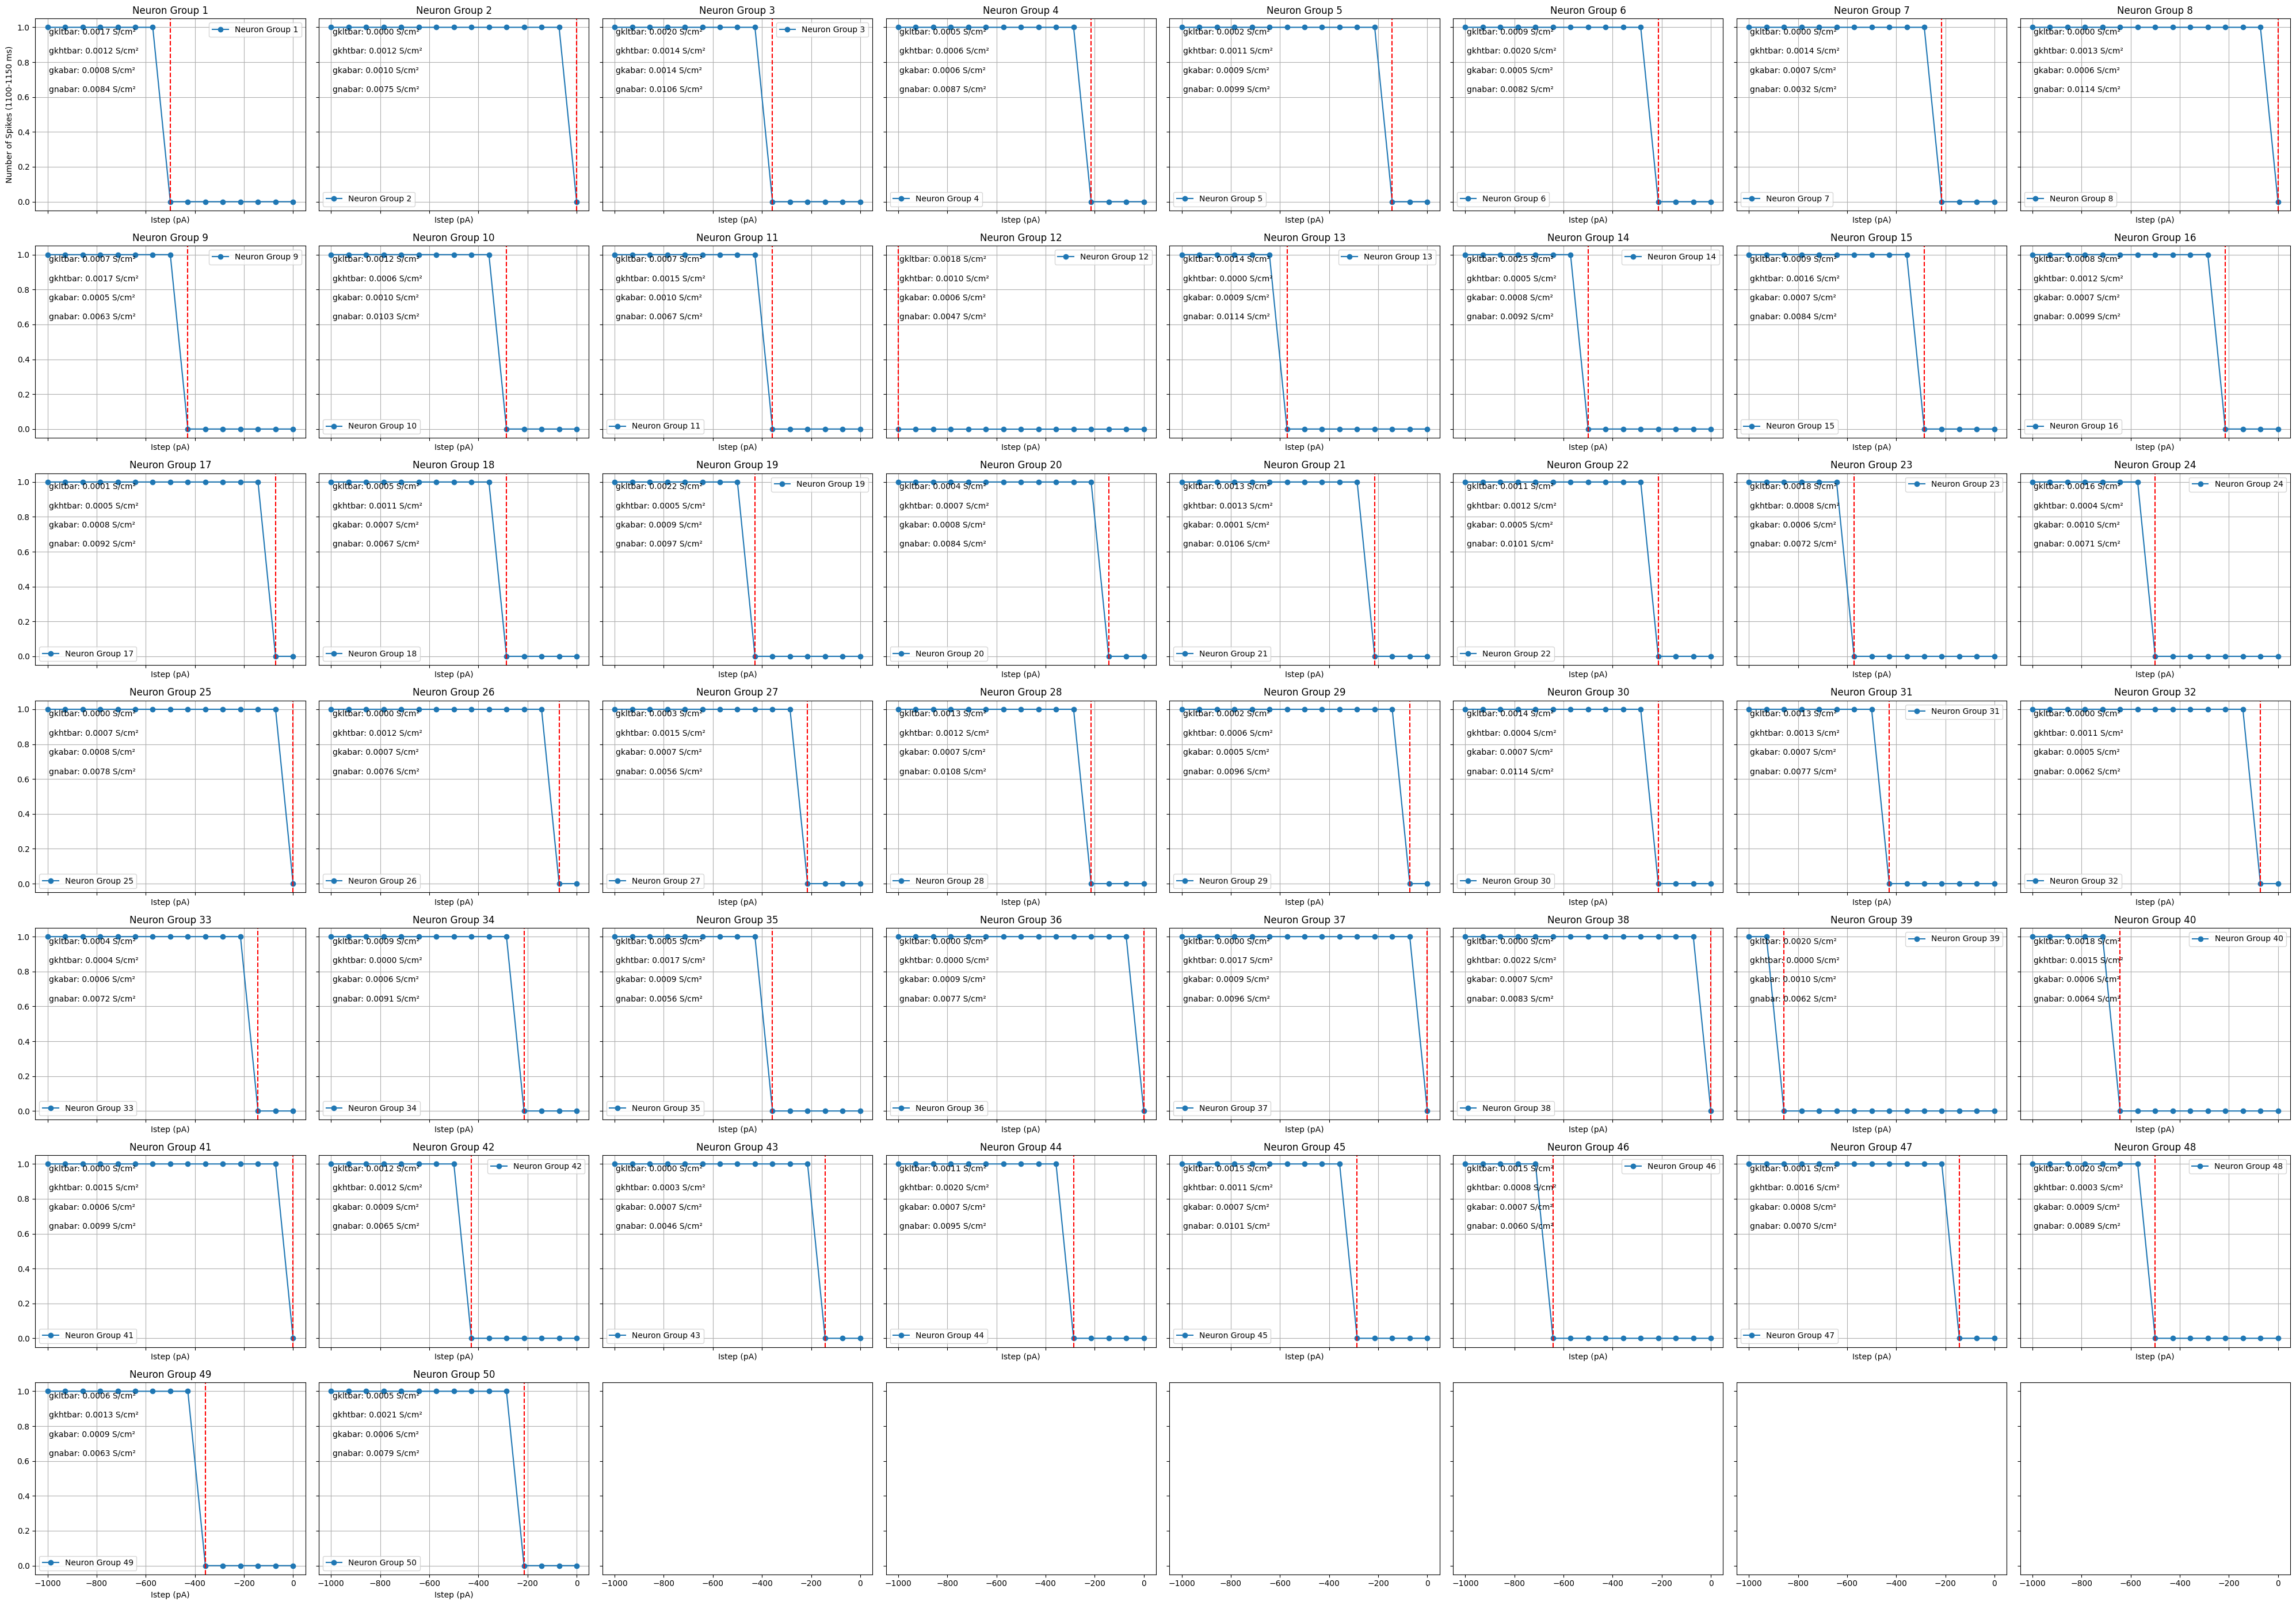

In [ ]:
# Spike analysis and plotting for all neuron groups in a grid of subplots
#start_time = 1100 * ms  # Start of the counting window
#end_time = 1150 * ms    # End of the counting window

start_time = 300*ms
end_time = 350*ms

# Automatically determine grid dimensions
num_cols = math.ceil(math.sqrt(num_groups))
num_rows = math.ceil(num_groups / num_cols)


# Create a grid of subplots
fig, axs = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 4*num_rows), sharex=True, sharey=True)

spike_counts = []  # Initialize an empty list to store spike counts for all neuron groups
transition_currents = []  # Initialize an empty list to store the transition currents

for i, neurons in enumerate(neuron_groups):  # Iterate through neuron groups with their indices
    monitor = spike_monitors[i]  # Get the corresponding SpikeMonitor
    spike_counts_neuron = []  # Initialize a list for this neuron group's counts

    for current_level, neuron_index in zip(Istep, range(N)):  # Iterate through Istep and neuron indices
        spike_times_in_window = monitor.t[
            (monitor.t >= start_time) &
            (monitor.t <= end_time) &
            (monitor.i == neuron_index)  # Select spikes for the specific neuron
        ]

        spike_counts_neuron.append(len(spike_times_in_window))  # Append spike count for this neuron

    spike_counts.append(spike_counts_neuron)  # Append the entire neuron group's counts

    # Determine subplot indices
    row_index = i // num_cols  # Integer division to get row index
    col_index = i % num_cols  # Modulo operator to get column index

    # Handle axs indexing based on whether it's a 1D or 2D array
    if num_rows == 1 or num_cols == 1:
        if num_rows == 1 and num_cols == 1:
            ax = axs
        elif num_rows == 1:
            ax = axs[col_index]
        else: # num_cols == 1
            ax = axs[row_index]
    else:
        ax = axs[row_index, col_index]


    # Plot for the current neuron group in the appropriate subplot
    ax.plot(Istep / pA, spike_counts_neuron, marker='o', linestyle='-', label=neuron_labels[i])
    ax.set_xlabel('Istep (pA)')  # Set x-axis label for each subplot
    ax.set_title(neuron_labels[i])  # Set title with neuron group label
    ax.grid(True)
    ax.legend()  # Add legend to the subplot

    # Embed gkltbar and gkhtbar values as text annotations
    gkltbar_value = neurons.gkltbar[0] / (siemens/cm**2)
    gkhtbar_value = neurons.gkhtbar[0] / (siemens/cm**2)
    gnabar_value = neurons.gnabar[0] / (siemens/cm**2)
    gkabar_value = neurons.gkabar[0] / (siemens/cm**2)
    ax.text(0.05, 0.95, f'gkltbar: {gkltbar_value:.4f} S/cm²', transform=ax.transAxes, verticalalignment='top')
    ax.text(0.05, 0.85, f'gkhtbar: {gkhtbar_value:.4f} S/cm²', transform=ax.transAxes, verticalalignment='top')
    ax.text(0.05, 0.75, f'gkabar: {gkabar_value:.4f} S/cm²', transform=ax.transAxes, verticalalignment='top')
    ax.text(0.05, 0.65, f'gnabar: {gnabar_value:.4f} S/cm²', transform=ax.transAxes, verticalalignment='top')


    # Find transition current
    try:
        transition_index = next(i for i, count in enumerate(spike_counts_neuron) if count == 0)
        transition_current = Istep[transition_index] / pA  # Convert to pA
        transition_currents.append(transition_current)

        # Add a vertical line to indicate the transition point
        ax.axvline(x=transition_current, color='r', linestyle='--')

        # Print or store the transition current
        print(f"Neuron Group {i+1}: Transition current = {transition_current:.2f} pA")
    except StopIteration:
        print(f"Neuron Group {i+1}: Did not stop spiking within the given current range.")

# Set y-axis label for the first subplot in the first column
# Need to handle the case where axs is a single Axes object
if num_rows == 1 and num_cols == 1:
    axs.set_ylabel('Number of Spikes (1100-1150 ms)')
elif num_cols == 1:
    axs[0].set_ylabel('Number of Spikes (1100-1150 ms)')
else:
    axs[0, 0].set_ylabel('Number of Spikes (1100-1150 ms)')


plt.tight_layout()
plt.show()

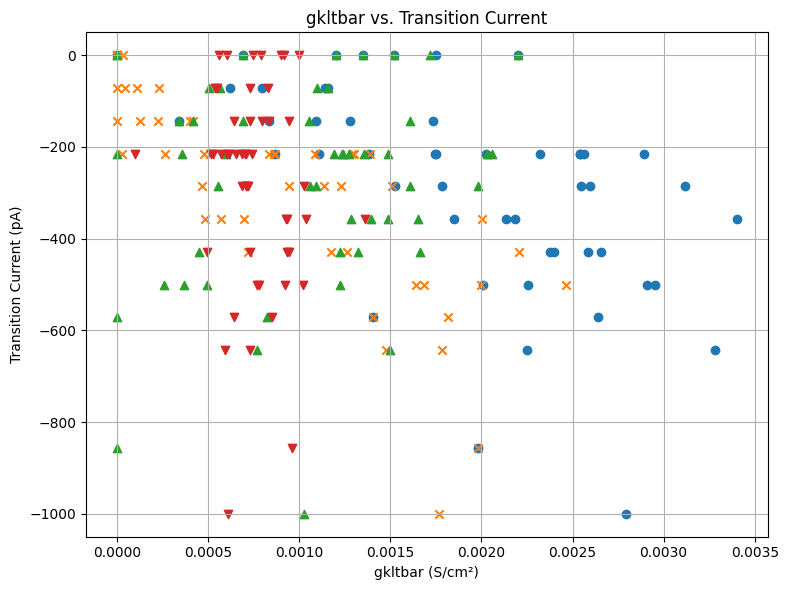

<Figure size 640x480 with 0 Axes>

In [ ]:
# Collect gkltbar values
gkltbar_values = [neurons.gkltbar[0] / (siemens/cm**2) for neurons in neuron_groups]
gkhtbar_values = [neurons.gkhtbar[0] / (siemens/cm**2) for neurons in neuron_groups]
gnabar_values = [neurons.gnabar[0] / (siemens/cm**2) for neurons in neuron_groups]
gkabar_values = [neurons.gkabar[0]/ (siemens/cm**2) for neurons in neuron_groups]
ghbar_values = [neurons.ghbar[0]/ (siemens/cm**2) for neurons in neuron_groups]

# Create a scatter plot of gkltbar vs. transition current
transition_currents_padded = transition_currents + [None] * (len(gkltbar_values) - len(transition_currents))

fig, ax = plt.subplots(figsize=(8, 6))
x_values = [gkl + gkh for gkl, gkh in zip(gkltbar_values, gkhtbar_values)]
ax.scatter(x_values, transition_currents_padded, marker='o')
ax.scatter(gkltbar_values, transition_currents_padded, marker='x')
ax.scatter(gkhtbar_values, transition_currents_padded, marker='^')
ax.scatter(gkabar_values, transition_currents_padded, marker='v')
ax.set_xlabel('gkltbar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('gkltbar vs. Transition Current')
ax.grid(True)

plt.tight_layout()
plt.show()
ax.set_title('gkltbar vs. Transition Current')
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#START STATISTICAL ANALYSIS TO TEST FOR SIGNIFICANT DEPENDENCE OF each conductance to the transition current
import statsmodels.api as sm

# Replace None values with 0 and filter out corresponding gkltbar_values
# filtered_gkltbar_values = [gkltbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None] # Original filtering
# filtered_transition_currents = [0 if tc is None else tc for tc in transition_currents_padded] # Original filtering

# Filter out None and -1000 pA  (minI) values from transition_currents_padded and corresponding parameter values
filtered_gkltbar_values = [gkltbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None and tc != -1000]
filtered_gkhtbar_values = [gkhtbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None and tc != -1000]
filtered_gnabar_values = [gnabar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None and tc != -1000]
filtered_gkabar_values = [gkabar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None and tc != -1000]
filtered_ghbar_values = [ghbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None and tc != -1000]

# Filter out None and -1000 pA (minI) values from transition_currents_padded
filtered_transition_currents = [tc for tc in transition_currents_padded if tc is not None and tc != -1000]


# Add a constant to the independent variable for the regression analysis
X = sm.add_constant(filtered_gkltbar_values)

# Create the OLS (Ordinary Least Squares) model
model = sm.OLS(filtered_transition_currents, X)

# Fit the model
results = model.fit()

# Print the summary of the regression results
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     84.71
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           3.56e-12
Time:                        23:24:28   Log-Likelihood:                -315.55
No. Observations:                  50   AIC:                             635.1
Df Residuals:                      48   BIC:                             638.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -72.5463     29.985     -2.419      0.0

In [ ]:
# Run a regression test for gkhtbar_values vs. transition_currents
# Add a constant to the independent variable for the regression analysis
X_gkht = sm.add_constant(filtered_gkhtbar_values)

# Create the OLS (Ordinary Least Squares) model
model_gkht = sm.OLS(filtered_transition_currents, X_gkht)

# Fit the model
results_gkht = model_gkht.fit()

# Print the summary of the regression results
print(results_gkht.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.979
Date:                Mon, 13 Oct 2025   Prob (F-statistic):              0.166
Time:                        23:24:28   Log-Likelihood:                -339.97
No. Observations:                  50   AIC:                             683.9
Df Residuals:                      48   BIC:                             687.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -364.6643     65.166     -5.596      0.0

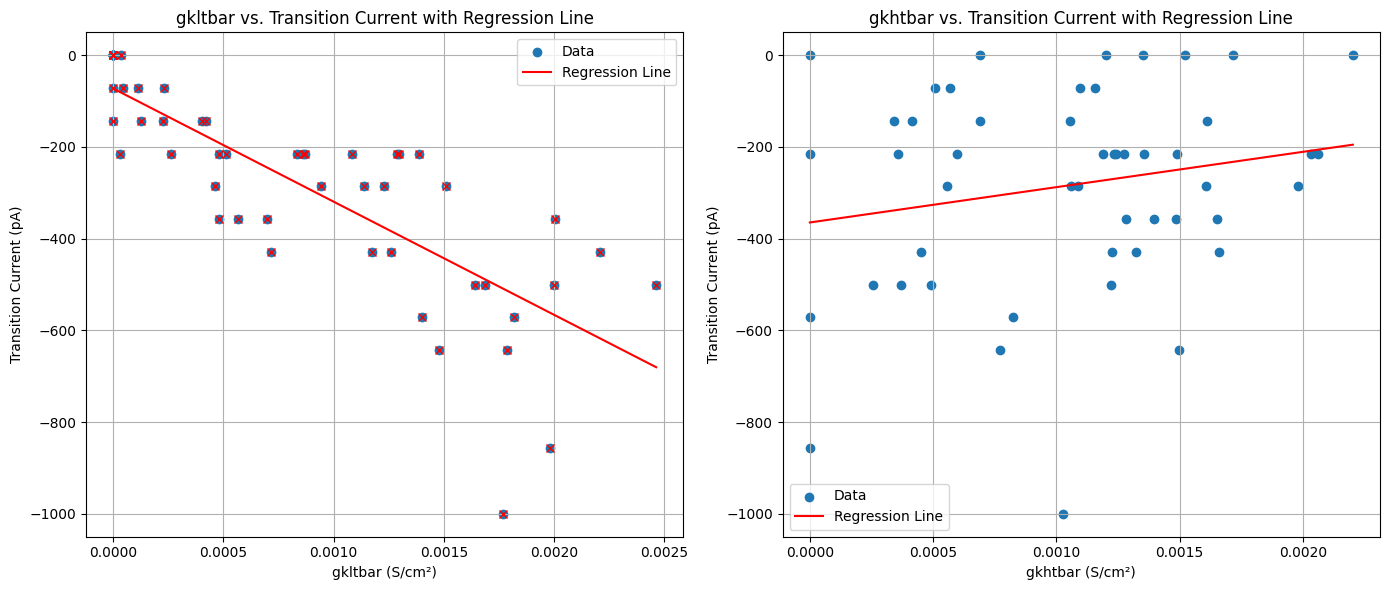

In [ ]:
# Generate predicted values for the regression lines
# For gkltbar
x_gklt = np.linspace(min(gkltbar_values), max(gkltbar_values), 100)
y_gklt_pred = results.predict(sm.add_constant(x_gklt))

# For gkhtbar
x_gkht = np.linspace(min(gkhtbar_values), max(gkhtbar_values), 100)
y_gkht_pred = results_gkht.predict(sm.add_constant(x_gkht))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot for gkltbar
axes[0].scatter(gkltbar_values, transition_currents_padded, label='Data')
axes[0].plot(filtered_gkltbar_values,filtered_transition_currents,'rx')
axes[0].plot(x_gklt, y_gklt_pred, color='red', label='Regression Line')
axes[0].set_xlabel('gkltbar (S/cm²)')
axes[0].set_ylabel('Transition Current (pA)')
axes[0].set_title('gkltbar vs. Transition Current with Regression Line')
axes[0].legend()
axes[0].grid(True)

# Plot for gkhtbar
axes[1].scatter(gkhtbar_values, transition_currents_padded, label='Data')
axes[1].plot(x_gkht, y_gkht_pred, color='red', label='Regression Line')
axes[1].set_xlabel('gkhtbar (S/cm²)')
axes[1].set_ylabel('Transition Current (pA)')
axes[1].set_title('gkhtbar vs. Transition Current with Regression Line')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     4.286
Date:                Mon, 13 Oct 2025   Prob (F-statistic):             0.0438
Time:                        23:24:28   Log-Likelihood:                -338.84
No. Observations:                  50   AIC:                             681.7
Df Residuals:                      48   BIC:                             685.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -555.6927    134.625     -4.128      0.0

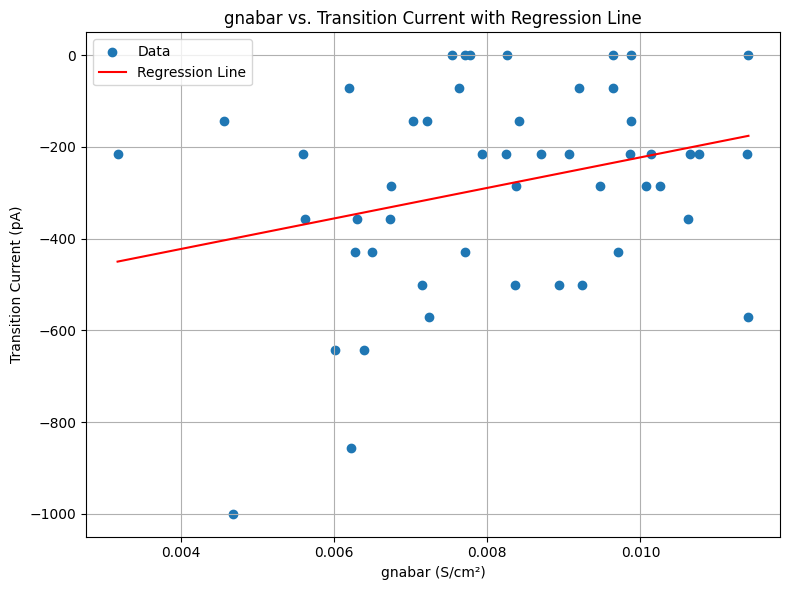

In [ ]:
# Add a constant to the independent variable for the regression analysis
X_gnabar = sm.add_constant(filtered_gnabar_values)

# Create the OLS (Ordinary Least Squares) model
model_gnabar = sm.OLS(filtered_transition_currents, X_gnabar)

# Fit the model
results_gnabar = model_gnabar.fit()

# Print the summary of the regression results
print(results_gnabar.summary())

# Generate predicted values for the regression line for gnabar
x_gnabar = np.linspace(min(gnabar_values), max(gnabar_values), 100)
y_gnabar_pred = results_gnabar.predict(sm.add_constant(x_gnabar))

# Create scatter plot with regression line
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(gnabar_values, transition_currents_padded, label='Data')
ax.plot(x_gnabar, y_gnabar_pred, color='red', label='Regression Line')
ax.set_xlabel('gnabar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('gnabar vs. Transition Current with Regression Line')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.7523
Date:                Mon, 13 Oct 2025   Prob (F-statistic):              0.390
Time:                        23:24:28   Log-Likelihood:                -340.59
No. Observations:                  50   AIC:                             685.2
Df Residuals:                      48   BIC:                             689.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -178.1450    126.419     -1.409      0.1

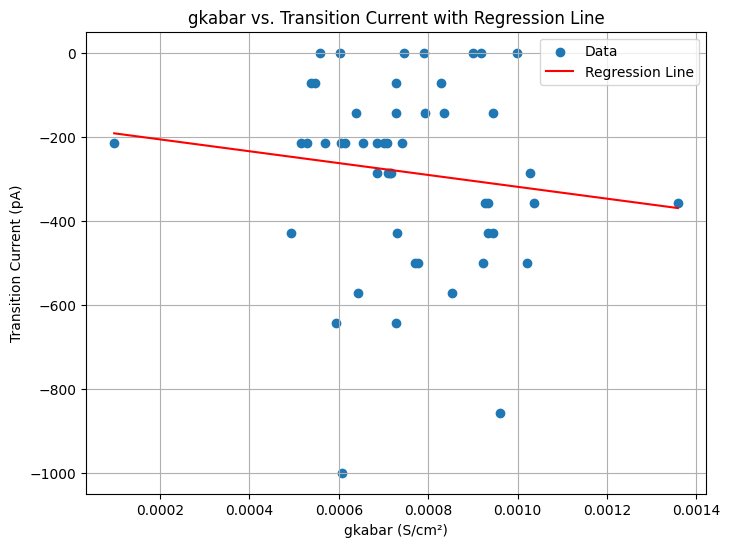

In [ ]:
# Add a constant to the independent variable for the regression analysis
X_gkabar = sm.add_constant(filtered_gkabar_values)

# Create the OLS (Ordinary Least Squares) model
model_gkabar = sm.OLS(filtered_transition_currents, X_gkabar)

# Fit the model
results_gkabar = model_gkabar.fit()

# Print the summary of the regression results
print(results_gkabar.summary())

fig, ax = plt.subplots(figsize=(8, 6))
x_gkabar = np.linspace(min(filtered_gkabar_values), max(filtered_gkabar_values), 100)
y_gkabar_pred = results_gkabar.predict(sm.add_constant(x_gkabar))
ax.scatter(filtered_gkabar_values, filtered_transition_currents, label='Data')
ax.plot(x_gkabar, y_gkabar_pred, color='red', label='Regression Line')
ax.set_xlabel('gkabar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('gkabar vs. Transition Current with Regression Line')
ax.legend()
ax.grid(True)

In [ ]:
'''
# Filter out None values and corresponding ghbar_values
filtered_ghbar_values = [ghbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None]
filtered_transition_currents = [tc for tc in transition_currents_padded if tc is not None]

# Add a constant to the independent variable for the regression analysis
X_ghbar = sm.add_constant(filtered_ghbar_values)

# Create the OLS (Ordinary Least Squares) model
model_ghbar = sm.OLS(filtered_transition_currents, X_ghbar)

# Fit the model
results_ghbar = model_ghbar.fit()

# Print the summary of the regression results
print(results_ghbar.summary())

# Generate the scatter plot with the regression line
fig, ax = plt.subplots(figsize=(8, 6))
x_ghbar = np.linspace(min(filtered_ghbar_values), max(filtered_ghbar_values), 100)
y_ghbar_pred = results_ghbar.predict(sm.add_constant(x_ghbar))

ax.scatter(filtered_ghbar_values, filtered_transition_currents, label='Data')
ax.plot(x_ghbar, y_ghbar_pred, color='red', label='Regression Line')
ax.set_xlabel('ghbar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('ghbar vs. Transition Current with Regression Line')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()
'''

"\n# Filter out None values and corresponding ghbar_values\nfiltered_ghbar_values = [ghbar_values[i] for i, tc in enumerate(transition_currents_padded) if tc is not None]\nfiltered_transition_currents = [tc for tc in transition_currents_padded if tc is not None]\n\n# Add a constant to the independent variable for the regression analysis\nX_ghbar = sm.add_constant(filtered_ghbar_values)\n\n# Create the OLS (Ordinary Least Squares) model\nmodel_ghbar = sm.OLS(filtered_transition_currents, X_ghbar)\n\n# Fit the model\nresults_ghbar = model_ghbar.fit()\n\n# Print the summary of the regression results\nprint(results_ghbar.summary())\n\n# Generate the scatter plot with the regression line\nfig, ax = plt.subplots(figsize=(8, 6))\nx_ghbar = np.linspace(min(filtered_ghbar_values), max(filtered_ghbar_values), 100)\ny_ghbar_pred = results_ghbar.predict(sm.add_constant(x_ghbar))\n\nax.scatter(filtered_ghbar_values, filtered_transition_currents, label='Data')\nax.plot(x_ghbar, y_ghbar_pred, color='

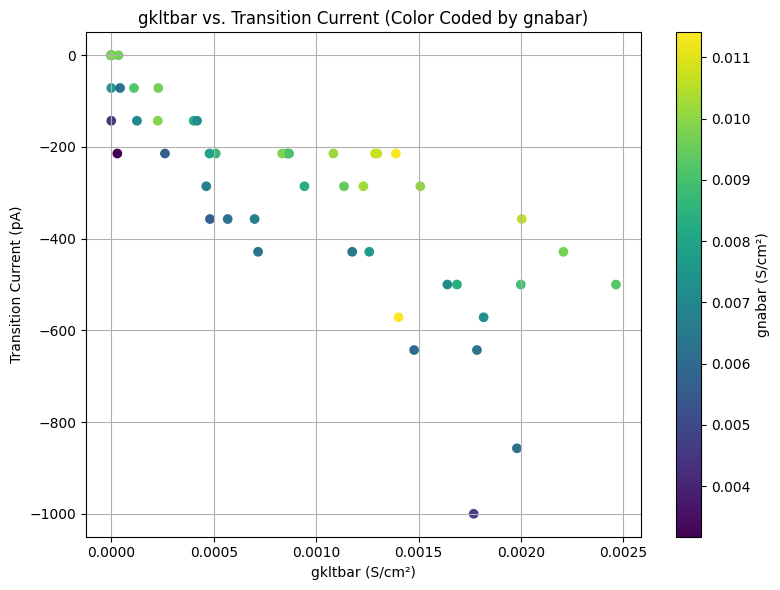

In [ ]:
# Filter out None values and corresponding parameter values for plotting
# Create the scatter plot with color coding
fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(filtered_gkltbar_values, filtered_transition_currents, c=filtered_gnabar_values, cmap='viridis')

ax.set_xlabel('gkltbar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('gkltbar vs. Transition Current (Color Coded by gnabar)')
ax.grid(True)

# Add a color bar
cbar = fig.colorbar(scatter)
cbar.set_label('gnabar (S/cm²)')

plt.tight_layout()
plt.show()

In [ ]:
# Define the divisions for gnabar values (e.g., based on percentiles or equal ranges)
# Let's use quantiles to create three groups with roughly equal numbers of data points
low_gnabar_threshold = np.percentile(filtered_gnabar_values, 33.3)
high_gnabar_threshold = np.percentile(filtered_gnabar_values, 66.7)

# Create lists to store filtered data for each group
low_gnabar_gkltbar = []
low_gnabar_transition = []
medium_gnabar_gkltbar = []
medium_gnabar_transition = []
high_gnabar_gkltbar = []
high_gnabar_transition = []

# Filter data into the three groups
for gklt, trans, gna in zip(filtered_gkltbar_values, filtered_transition_currents, filtered_gnabar_values):
    if gna <= low_gnabar_threshold:
        low_gnabar_gkltbar.append(gklt)
        low_gnabar_transition.append(trans)
    elif gna <= high_gnabar_threshold:
        medium_gnabar_gkltbar.append(gklt)
        medium_gnabar_transition.append(trans)
    else:
        high_gnabar_gkltbar.append(gklt)
        high_gnabar_transition.append(trans)

print(f"Number of data points in low gnabar group: {len(low_gnabar_transition)}")
print(f"Number of data points in medium gnabar group: {len(medium_gnabar_transition)}")
print(f"Number of data points in high gnabar group: {len(high_gnabar_transition)}")

Number of data points in low gnabar group: 17
Number of data points in medium gnabar group: 16
Number of data points in high gnabar group: 17


In [ ]:
# Perform regression for the low gnabar group
if low_gnabar_gkltbar: # Check if the list is not empty
    X_low = sm.add_constant(low_gnabar_gkltbar)
    model_low = sm.OLS(low_gnabar_transition, X_low)
    results_low = model_low.fit()
    print("--- Regression Results for Low gnabar Group ---")
    print(results_low.summary())
else:
    print("Low gnabar group is empty, cannot perform regression.")

# Perform regression for the medium gnabar group
if medium_gnabar_gkltbar: # Check if the list is not empty
    X_medium = sm.add_constant(medium_gnabar_gkltbar)
    model_medium = sm.OLS(medium_gnabar_transition, X_medium)
    results_medium = model_medium.fit()
    print("\n--- Regression Results for Medium gnabar Group ---")
    print(results_medium.summary())
else:
    print("Medium gnabar group is empty, cannot perform regression.")


# Perform regression for the high gnabar group
if high_gnabar_gkltbar: # Check if the list is not empty
    X_high = sm.add_constant(high_gnabar_gkltbar)
    model_high = sm.OLS(high_gnabar_transition, X_high)
    results_high = model_high.fit()
    print("\n--- Regression Results for High gnabar Group ---")
    print(results_high.summary())
else:
    print("High gnabar group is empty, cannot perform regression.")

--- Regression Results for Low gnabar Group ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     83.94
Date:                Mon, 13 Oct 2025   Prob (F-statistic):           1.56e-07
Time:                        23:24:29   Log-Likelihood:                -102.19
No. Observations:                  17   AIC:                             208.4
Df Residuals:                      15   BIC:                             210.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

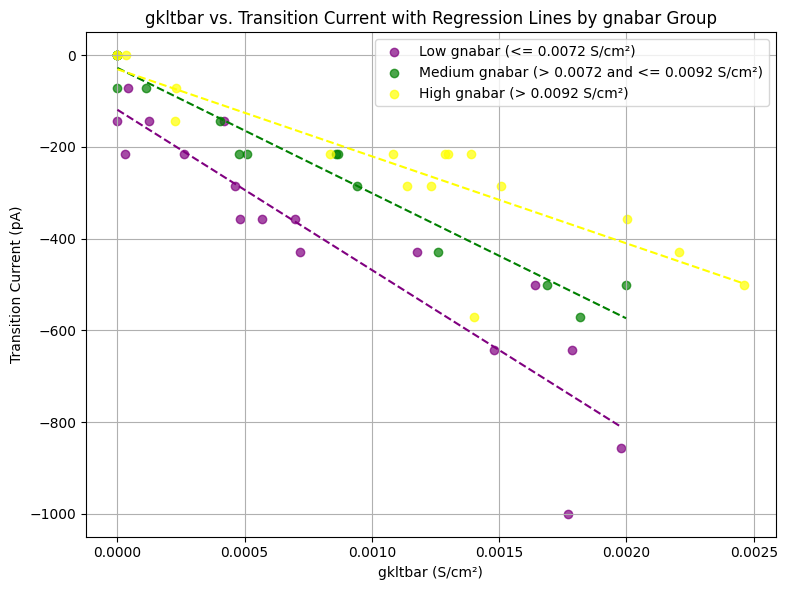

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define colors for each gnabar group
colors = ['purple', 'green', 'yellow'] # Corresponding to low, medium, high gnabar (matching the viridis colormap generally)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot for each group
ax.scatter(low_gnabar_gkltbar, low_gnabar_transition, color=colors[0], label=f'Low gnabar (<= {low_gnabar_threshold:.4f} S/cm²)', alpha=0.7)
ax.scatter(medium_gnabar_gkltbar, medium_gnabar_transition, color=colors[1], label=f'Medium gnabar (> {low_gnabar_threshold:.4f} and <= {high_gnabar_threshold:.4f} S/cm²)', alpha=0.7)
ax.scatter(high_gnabar_gkltbar, high_gnabar_transition, color=colors[2], label=f'High gnabar (> {high_gnabar_threshold:.4f} S/cm²)', alpha=0.7)

# Plot regression lines
# Low gnabar group
if low_gnabar_gkltbar:
    x_low = np.linspace(min(low_gnabar_gkltbar), max(low_gnabar_gkltbar), 100)
    y_low_pred = results_low.predict(sm.add_constant(x_low))
    ax.plot(x_low, y_low_pred, color=colors[0], linestyle='--')

# Medium gnabar group
if medium_gnabar_gkltbar:
    x_medium = np.linspace(min(medium_gnabar_gkltbar), max(medium_gnabar_gkltbar), 100)
    y_medium_pred = results_medium.predict(sm.add_constant(x_medium))
    ax.plot(x_medium, y_medium_pred, color=colors[1], linestyle='--')

# High gnabar group
if high_gnabar_gkltbar:
    x_high = np.linspace(min(high_gnabar_gkltbar), max(high_gnabar_gkltbar), 100)
    y_high_pred = results_high.predict(sm.add_constant(x_high))
    ax.plot(x_high, y_high_pred, color=colors[2], linestyle='--')

ax.set_xlabel('gkltbar (S/cm²)')
ax.set_ylabel('Transition Current (pA)')
ax.set_title('gkltbar vs. Transition Current with Regression Lines by gnabar Group')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

THIS NEXT SECTION SAVES DATA and GIVES EXAMPLE CODE FOR LOADING the DATA.

In [ ]:

# SAVE THE DATA
import numpy as np
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the path to the desired folder in Google Drive
drive_folder_path = '/content/drive/MyDrive/AnodeBreak' # Assuming your Colab file is in MyDrive

# Create the folder if it doesn't exist
if not os.path.exists(drive_folder_path):
    os.makedirs(drive_folder_path)
    print(f"Created folder: {drive_folder_path}")

# Define the full path for the data file
file_path = os.path.join(drive_folder_path, 'simulation_data3_RittDRG_JaggerSGN_IKA_widerrangehighres.npz')

# Collect data from state monitors (example: saving 'v' and 'I')
# You would need to adapt this based on what you recorded in StateMonitor
state_data = {f'neuron_group_{i}': {'v': mon.v[:], 'I': mon.I[:]} for i, mon in enumerate(state_monitors)}

# Collect data from spike monitors
spike_data = {f'neuron_group_{i}': {'t': mon.t[:], 'i': mon.i[:]} for i, mon in enumerate(spike_monitors)}


# Save the variables to the specified path
np.savez(file_path,
         transition_currents=transition_currents_padded,
         gkltbar_values=gkltbar_values,
         gkhtbar_values=gkhtbar_values,
         gnabar_values=gnabar_values,
         gkabar_values=gkabar_values,
         ghbar_values=ghbar_values,
         state_data=state_data,
         spike_data=spike_data)

print(f"Simulation data saved to {file_path}")


ValueError: mount failed

In [ ]:
'''
#IMPORT SAVED DATA
import numpy as np
import matplotlib.pyplot as plt
import os
from google.colab import drive

# Mount Google Drive (if not already mounted)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Define the path to the desired folder in Google Drive
drive_folder_path = '/content/drive/MyDrive/AnodeBreak'
file_path = os.path.join(drive_folder_path, 'simulation_data3_RittDRG_JaggerSGN_IKA.npz')

# Reload the data from the NPZ file
data = np.load(file_path, allow_pickle=True)

transition_currents_padded = data['transition_currents']
gkltbar_values = data['gkltbar_values']
gkhtbar_values = data['gkhtbar_values']
gnabar_values = data['gnabar_values']
gkabar_values = data['gkabar_values']
ghbar_values = data['ghbar_values']
'''

In [ ]:
who
